---
### 05. 다중분류 - MNIST
---

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from google.colab import drive
drive.mount('/content/drive')
os.chdir('/content/drive/MyDrive/10Days_Pytorch')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import *

import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
from torch.optim import Adam

device = 'cuda' if torch.cuda.is_available() else 'cpu'

Mounted at /content/drive


In [2]:
# make dataset ~ 다중분류용 새로 생성
def make_DataSet(X_train, X_val, y_train, y_val, batch_size=32):
  X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
  y_train_tensor = torch.tensor(y_train, dtype=torch.long)
  X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
  y_val_tensor = torch.tensor(y_val, dtype=torch.long)
  train_dataset = TensorDataset(X_train_tensor, y_train_tensor)

  train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
  return train_loader, X_val_tensor, y_val_tensor

# train
def train(dataloader, model, loss_fn, optimizer, device):
  size = len(dataloader.dataset)
  num_batches = len(dataloader)
  tr_loss = 0

  model.train()
  for X, y in dataloader:
    X, y = X.to(device), y.to(device)

    pred = model(X)
    loss = loss_fn(pred, y)
    tr_loss += loss

    loss.backward()
    optimizer.step()
    optimizer.zero_grad()

  tr_loss /= num_batches
  return tr_loss.item()

# evaluate
def evaluate(X_val_tensor, y_val_tensor, model, loss_fn, device):
  model.eval()
  with torch.no_grad():
    X, y = X_val_tensor.to(device), y_val_tensor.to(device)
    pred = model(X)
    eval_loss = loss_fn(pred, y).item()
  return eval_loss, pred

# vizualize
def learning_curve(tr_loss_list, val_loss_list):
  epochs = list(range(1, len(tr_loss_list)+1))
  plt.plot(epochs, tr_loss_list, label='tr_err', marker='.')
  plt.plot(epochs, val_loss_list, label='val_err', marker='.')
  plt.xlabel('epochs')
  plt.ylabel('loss')
  plt.legend()
  plt.grid()
  plt.show()

#### pytorch 내장 MNIST 데이터 다운로드

In [3]:
# data loading
from torchvision import datasets
from torchvision.transforms import ToTensor

train_dataset = datasets.MNIST(
    root='data',
    train=True,
    download=True,
    transform=ToTensor()
)

test_dataset = datasets.MNIST(
    root='data',
    train=False,
    download=True,
    transform=ToTensor()
)

Train data: torch.Size([60000, 28, 28]) torch.Size([60000])
Test data: torch.Size([10000, 28, 28]) torch.Size([10000])
Class: ['0 - zero', '1 - one', '2 - two', '3 - three', '4 - four', '5 - five', '6 - six', '7 - seven', '8 - eight', '9 - nine']


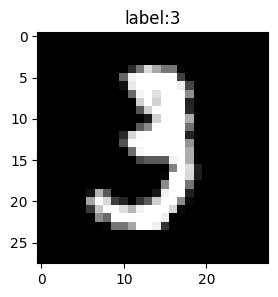

In [4]:
# 데이터 확인
print('Train data:', train_dataset.data.shape, train_dataset.targets.shape)
print('Test data:', test_dataset.data.shape, test_dataset.targets.shape)
print('Class:', train_dataset.classes)

k = 10
image, label = train_dataset.data[k], train_dataset.targets[k]
plt.figure(figsize=(3,3))
plt.imshow(image, cmap='grey')
plt.title(f'label:{label}')
plt.show()

#### 데이터 전처리
- MNIST 데이터는 타겟분리, 스케일링이 모두 적용되어 있음
- 따라서 검증용 데이터 분리와 데이터로더 구성만 필요  

In [5]:
# Data Loader
batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size)

In [6]:
# test dataset -> 검증용 5000건, 테스트용 5000건
X_val, X_test = test_dataset.data[:5000], test_dataset.data[5000:]
y_val, y_test = test_dataset.targets[:5000], test_dataset.targets[5000:]
print(X_val.shape, y_val.shape)

# X_val, X_test scaling
X_val = X_val/255
X_test = X_test/255

torch.Size([5000, 28, 28]) torch.Size([5000])


In [7]:
# 데이터 차원 변경
X_val = X_val.view(5000, 1, 28, 28)
X_test = X_test.view(5000, 1, 28, 28)
print(X_val.shape, y_val.shape)

torch.Size([5000, 1, 28, 28]) torch.Size([5000])


#### model

In [8]:
n_feature = 28*28
n_class = 10

model = nn.Sequential(
    nn.Flatten(),
    nn.Linear(n_feature, n_class)
).to(device)

loss_fn = nn.CrossEntropyLoss()
optimizer = Adam(model.parameters(), lr=0.001)

#### train

In [9]:
epochs = 10
tr_loss_list, val_loss_list = [],[]
for i in range(epochs):
  tr_loss = train(train_loader, model, loss_fn, optimizer, device)
  val_loss, _ = evaluate(X_val, y_val, model, loss_fn, device)
  tr_loss_list.append(tr_loss)
  val_loss_list.append(val_loss)
  print(f"epoch {i+1}, train loss: {tr_loss:.4f}, val loss:{val_loss:.4f}")

epoch 1, train loss: 0.5519, val loss:0.4282
epoch 2, train loss: 0.3291, val loss:0.3787
epoch 3, train loss: 0.3001, val loss:0.3604
epoch 4, train loss: 0.2862, val loss:0.3514
epoch 5, train loss: 0.2777, val loss:0.3462
epoch 6, train loss: 0.2717, val loss:0.3429
epoch 7, train loss: 0.2672, val loss:0.3407
epoch 8, train loss: 0.2636, val loss:0.3392
epoch 9, train loss: 0.2607, val loss:0.3381
epoch 10, train loss: 0.2582, val loss:0.3374


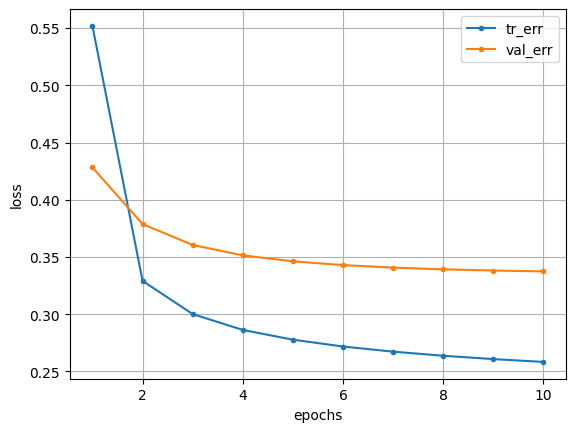

In [10]:
learning_curve(tr_loss_list, val_loss_list)

In [11]:
_, pred = evaluate(X_test, y_test, model, loss_fn, device)
pred = nn.functional.softmax(pred, dim=1)
pred = np.argmax(pred.cpu().numpy(), axis=1)
print(pred[:5])

[3 9 9 8 4]


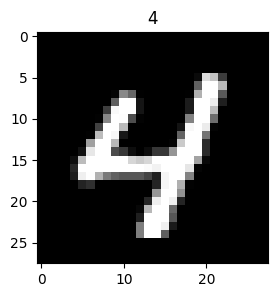

In [12]:
j = 4
image, label = test_dataset.data[5000+j], test_dataset.targets[5000+j]
plt.figure(figsize=(3,3))
plt.imshow(image, cmap='grey')
plt.title(f"{label}")
plt.show()

In [13]:
# evaluation
report = classification_report(y_test.numpy(), pred)
print(report)

              precision    recall  f1-score   support

           0       0.96      0.98      0.97       520
           1       0.98      0.98      0.98       564
           2       0.96      0.91      0.93       502
           3       0.96      0.92      0.94       510
           4       0.97      0.95      0.96       482
           5       0.93      0.92      0.93       436
           6       0.94      0.98      0.96       496
           7       0.96      0.96      0.96       516
           8       0.88      0.93      0.91       485
           9       0.93      0.95      0.94       489

    accuracy                           0.95      5000
   macro avg       0.95      0.95      0.95      5000
weighted avg       0.95      0.95      0.95      5000



#### Add layers

In [14]:
# model 변경
n_feature = 28*28
n_class = 10

model = nn.Sequential(
    nn.Flatten(),
    nn.Linear(n_feature, 20),
    nn.ReLU(),
    nn.Linear(20, n_class)
).to(device)

loss_fn = nn.CrossEntropyLoss()
optimizer = Adam(model.parameters(), lr=0.001)

In [15]:
epochs = 10
tr_loss_list, val_loss_list = [],[]
for i in range(epochs):
  tr_loss = train(train_loader, model, loss_fn, optimizer, device)
  val_loss, _ = evaluate(X_val, y_val, model, loss_fn, device)
  tr_loss_list.append(tr_loss)
  val_loss_list.append(val_loss)
  print(f"epoch {i+1}, train loss: {tr_loss:.4f}, val loss:{val_loss:.4f}")

epoch 1, train loss: 0.5109, val loss:0.3689
epoch 2, train loss: 0.2676, val loss:0.3096
epoch 3, train loss: 0.2249, val loss:0.2692
epoch 4, train loss: 0.1925, val loss:0.2446
epoch 5, train loss: 0.1698, val loss:0.2273
epoch 6, train loss: 0.1538, val loss:0.2173
epoch 7, train loss: 0.1418, val loss:0.2090
epoch 8, train loss: 0.1323, val loss:0.2034
epoch 9, train loss: 0.1246, val loss:0.1978
epoch 10, train loss: 0.1183, val loss:0.1956


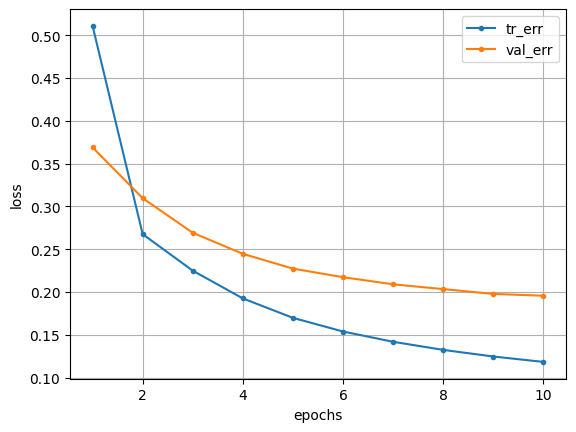

In [16]:
learning_curve(tr_loss_list, val_loss_list)

In [17]:
_, pred = evaluate(X_test, y_test, model, loss_fn, device)
pred = nn.functional.softmax(pred, dim=1)
pred = np.argmax(pred.cpu().numpy(), axis=1)

report = classification_report(y_test.numpy(), pred)
print(report)

              precision    recall  f1-score   support

           0       0.98      0.98      0.98       520
           1       0.99      0.99      0.99       564
           2       0.98      0.96      0.97       502
           3       0.97      0.95      0.96       510
           4       0.99      0.97      0.98       482
           5       0.91      0.99      0.95       436
           6       0.98      0.99      0.99       496
           7       0.97      0.98      0.98       516
           8       0.96      0.95      0.96       485
           9       0.97      0.97      0.97       489

    accuracy                           0.97      5000
   macro avg       0.97      0.97      0.97      5000
weighted avg       0.97      0.97      0.97      5000

